# Visualizing the branching process

ETAS is a **branching (cluster) process**: background "immigrant" events each seed a tree of
triggered descendants. The simulator records every event's `parent`, so we can reconstruct the
full forest. Here we collect the clusters and visualize one as a branching process — its
genealogy, its footprint in space, and how it grows.

Cluster tools live on `Catalog` (`cluster_roots`, `generation`, `clusters`) and in
`moment_etas.visualization.branching`. See `../spec.md` §6 for the branching simulation.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from moment_etas import Params, simulate_catalog
from moment_etas.visualization import branching

# near-critical triggering so clusters are large and multi-generation
cat = simulate_catalog(Params(mu0=2e-7, k=0.09, alpha=1.15), t_max=400 * 365.25, seed=7)
clusters = cat.clusters()
n_bg = (cat.parent == -1).sum()
print(f"{len(cat)} events, {n_bg} background → {len(clusters)} clusters")
print(f"largest clusters: {[len(c) for c in clusters[:8]]}")

5380 events, 298 background → 298 clusters
largest clusters: [2179, 1992, 472, 51, 50, 43, 33, 30]


## Cluster-size distribution

A branching-process signature: near criticality the cluster sizes are heavy-tailed (a few huge
families, many singletons). Log-log histogram of family sizes.

singletons (background with no offspring): 215 (72% of clusters)


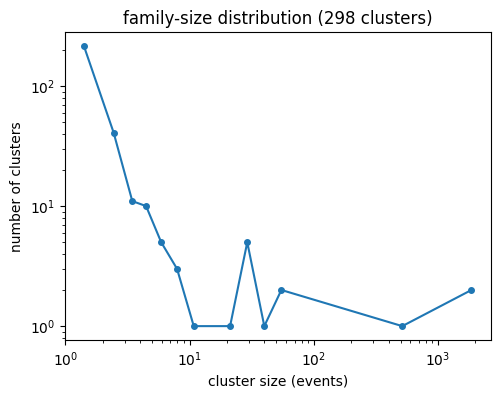

In [2]:
sizes = np.array([len(c) for c in clusters])
bins = np.unique(np.round(np.logspace(0, np.log10(sizes.max()), 25)).astype(int))
counts, edges = np.histogram(sizes, bins=bins)
centers = np.sqrt(edges[:-1] * edges[1:])

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.loglog(centers[counts > 0], counts[counts > 0], "o-", ms=4)
ax.set(xlabel="cluster size (events)", ylabel="number of clusters",
       title=f"family-size distribution ({len(clusters)} clusters)")
print(f"singletons (background with no offspring): {(sizes == 1).sum()} "
      f"({(sizes == 1).mean():.0%} of clusters)")

## Pick a cluster

For a readable family tree we want a moderate cluster (tens–low hundreds of events) with a sizable
root. The space-time map handles big clusters fine, so we also keep the largest for that.

In [3]:
gen = cat.generation()
moderate = [c for c in clusters if 30 <= len(c) <= 150]
members = max(moderate, key=lambda c: cat.m[c[0]])      # biggest root among moderate clusters
biggest = clusters[0]

root = members[0]
print(f"chosen cluster: {len(members)} events, root M{cat.m[root]:.1f}, "
      f"{gen[members].max()} generations, "
      f"span {(cat.t[members].max() - cat.t[root]) / 365.25:.1f} yr")
print(f"largest cluster: {len(biggest)} events, {gen[biggest].max()} generations")

chosen cluster: 30 events, root M5.1, 4 generations, span 19.3 yr
largest cluster: 2179 events, 14 generations


## 1. Genealogy — the family tree

Generation on the x-axis (the cascade fans left→right), tidy-tree layout on y, nodes sized by
magnitude and colored by time since the root. The root (red star) seeds direct aftershocks
(generation 1), some of which trigger their own, and so on. (Time isn't the x-axis because Omori
bunches the immediate aftershocks at t≈0 — it's shown by color instead.)

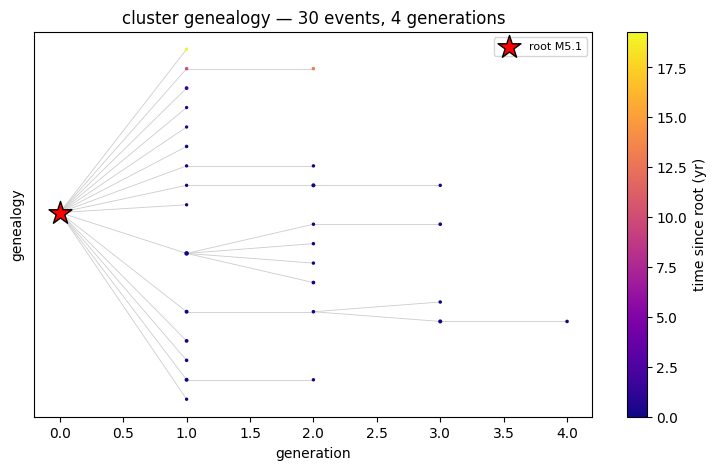

In [4]:
branching.cluster_tree(cat, members);

## 2. The cluster in space

The same branching embedded in the map: parent→child links colored by generation, nodes sized by
magnitude. Offspring land near their parent (the spatial kernel `d(M)=c_d·R(M)`) with a power-law
tail reaching further out. Left: the chosen cluster; right: the largest cluster.

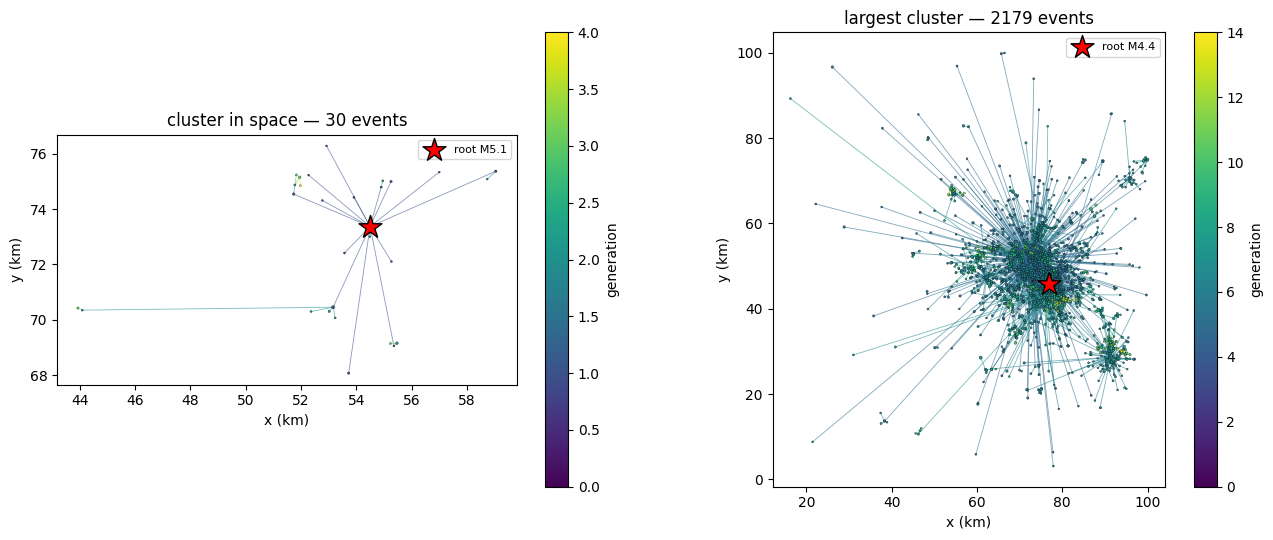

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
branching.cluster_map(cat, members, ax=axes[0])
branching.cluster_map(cat, biggest, ax=axes[1])
axes[1].set_title(f"largest cluster — {len(biggest)} events")
fig.tight_layout()

## 3. Growth and generations

Left: cumulative events since the root (the Omori-style cascade growth). Right: events per
generation — whether the cascade builds (each generation larger, near/super-critical) before
Omori decay and field depletion damp it out.

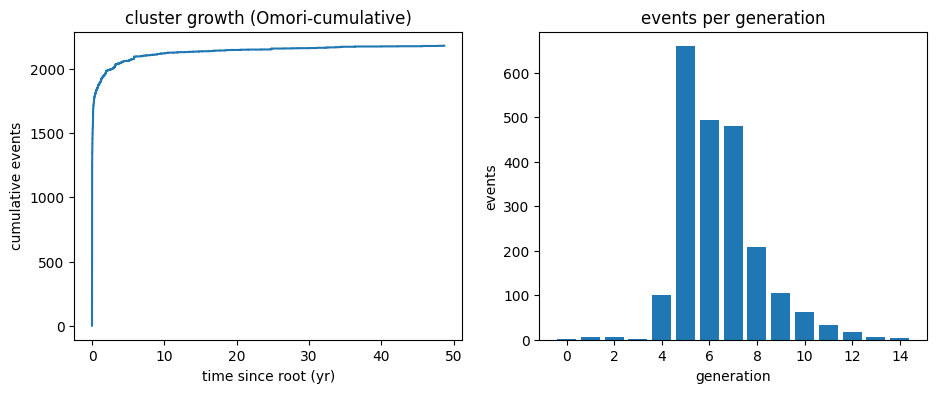

In [6]:
branching.cluster_diagnostics(cat, biggest);

## Notes

- **Cluster API**: `cat.clusters()` returns member-index arrays (largest first), `cat.generation()`
  the depth per event, `cat.cluster_roots()` the background ancestor. Tree edges within a cluster
  are `(cat.parent[i], i)` for non-root members.
- **Regime**: `alpha`, `k` control how branchy the clusters are; the near-critical settings here
  give deep, heavy-tailed families. Lower `k`/`alpha` → mostly singletons and shallow trees.
- **Moment coupling**: in this model a cascade also *depletes* the field, so very large families
  eventually self-limit (the core locks) — visible as the generation counts rolling over.